<a href="https://colab.research.google.com/github/castroirene28/Machine-Learning-Project-1/blob/main/Iced_Latte_Flavors_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET ==========
      Milk Sweetness          Flavor
0    Whole       Low         Vanilla
1      Oat    Medium         Caramel
2   Almond      High           Mocha
3    Whole    Medium         Vanilla
4      Soy       Low        Hazelnut
5      Oat      High           Mocha
6    Whole       Low         Caramel
7   Almond    Medium         Vanilla
8      Soy      High        Hazelnut
9    Whole       Low           Mocha
10     Oat    Medium         Vanilla
11   Whole      High         Caramel
12  Almond       Low        Hazelnut
13     Soy    Medium           Mocha
14   Whole      High         Vanilla
15     Oat       Low         Caramel
16  Almond    Medium           Mocha
17     Soy      High        Hazelnut
18   Whole    Medium         Vanilla
19     Oat       Low         Caramel
20   Whole    Medium   Cookie Butter
21     Oat      High   Pumpkin Spice
22  Almond       Low  Salted Caramel

========== MODEL RESULTS ==========
Accuracy: 0.14

Classification Report:
      

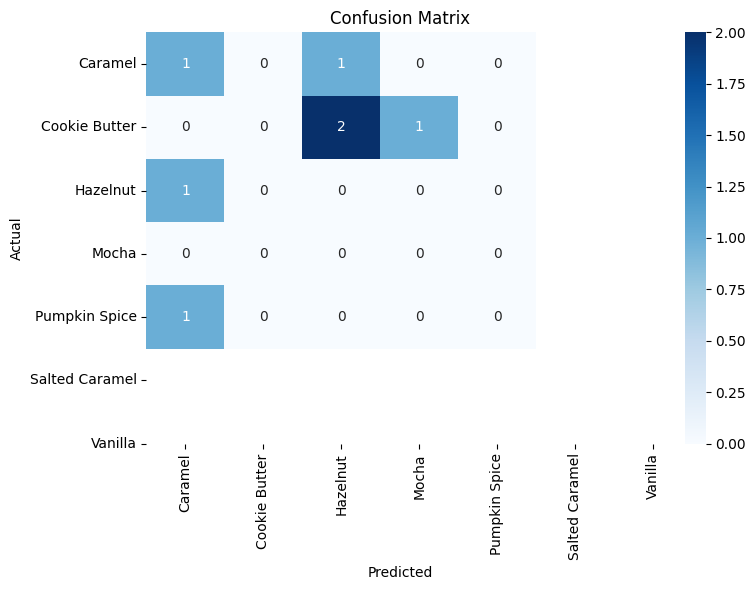

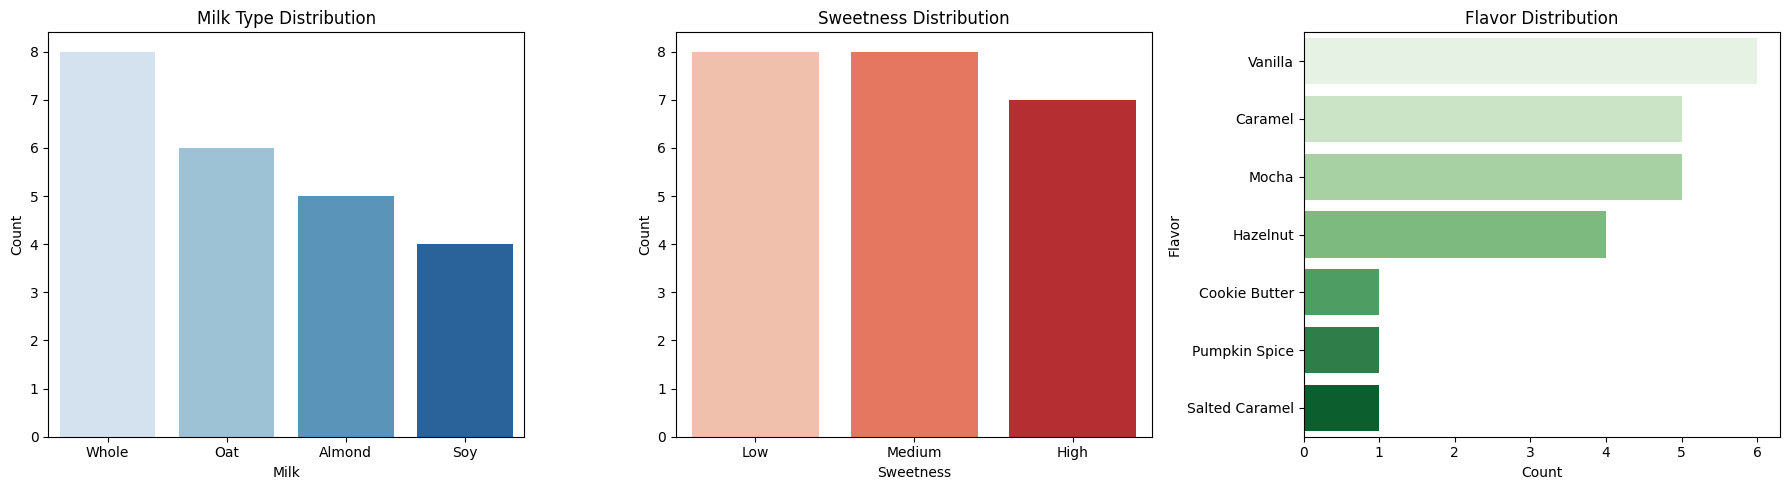


========== NEW PREDICTION ==========
Milk: Whole
Sweetness: Medium
Predicted Iced Latte Flavor: Vanilla


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create the dataset
data = {
    "Milk": [
        "Whole", "Oat", "Almond", "Whole", "Soy",
        "Oat", "Whole", "Almond", "Soy", "Whole",
        "Oat", "Whole", "Almond", "Soy", "Whole",
        "Oat", "Almond", "Soy", "Whole", "Oat",
        "Whole", "Oat", "Almond"
    ],

    "Sweetness": [
        "Low", "Medium", "High", "Medium", "Low",
        "High", "Low", "Medium", "High", "Low",
        "Medium", "High", "Low", "Medium", "High",
        "Low", "Medium", "High", "Medium", "Low",
        "Medium", "High", "Low"
    ],

    "Flavor": [
        "Vanilla", "Caramel", "Mocha", "Vanilla", "Hazelnut",
        "Mocha", "Caramel", "Vanilla", "Hazelnut", "Mocha",
        "Vanilla", "Caramel", "Hazelnut", "Mocha", "Vanilla",
        "Caramel", "Mocha", "Hazelnut", "Vanilla", "Caramel",
        "Cookie Butter", "Pumpkin Spice", "Salted Caramel"
    ]
}

df = pd.DataFrame(data)

print("========== DATASET ==========")
print(df)

# Encode the target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Flavor"])

# Define the features
X = df[["Milk", "Sweetness"]]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         ["Milk", "Sweetness"])
    ]
)

# Build the model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
print("\n========== MODEL RESULTS ==========")

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")

# Get the unique labels present in y_test and predictions
unique_labels_in_test = np.unique(np.concatenate((y_test, predictions)))

# Filter target_names to only include the labels present in the test set
filtered_target_names = label_encoder.classes_[unique_labels_in_test]

print(
    classification_report(
        y_test,
        predictions,
        labels=unique_labels_in_test,
        target_names=filtered_target_names,
        zero_division=0
    )
)

# Display the confusion matrix using only relevant labels
cm = confusion_matrix(y_test, predictions, labels=unique_labels_in_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=filtered_target_names,
    yticklabels=filtered_target_names
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Display bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    x="Milk",
    data=df,
    hue="Milk",
    palette="Blues",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Milk Type Distribution")
axes[0].set_xlabel("Milk")
axes[0].set_ylabel("Count")

sns.countplot(
    x="Sweetness",
    data=df,
    hue="Sweetness",
    palette="Reds",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Sweetness Distribution")
axes[1].set_xlabel("Sweetness")
axes[1].set_ylabel("Count")

sns.countplot(
    y="Flavor",
    data=df,
    hue="Flavor",
    palette="Greens",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Flavor Distribution")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Flavor")

plt.tight_layout()
plt.show()

# Predict a new customer's preferred flavor
new_customer = pd.DataFrame({
    "Milk": ["Whole"],
    "Sweetness": ["Medium"]
})

prediction = model.predict(new_customer)
predicted_flavor = label_encoder.inverse_transform(prediction)

print("\n========== NEW PREDICTION ==========")
print("Milk: Whole")
print("Sweetness: Medium")
print("Predicted Iced Latte Flavor:", predicted_flavor[0])